# NLP-Based Sentiment Analysis of IMDB Movie Reviews

This project uses Natural Language Processing (NLP) techniques
to classify IMDB movie reviews as positive or negative.

In [73]:
import pandas as pd
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


In [74]:
import pandas as pd

# Load the dataset, specifying no header as the first row is data
df = pd.read_csv("IMDB Dataset.csv", header=None)

# Rename the relevant columns and drop the rest
# Based on inspection, column 0 is the review and column 1 is the sentiment
df = df[[0, 1]]
df.columns = ['review', 'sentiment']

# Drop the first row (index 0) as it appears to be a malformed entry
df = df.drop(index=0).reset_index(drop=True)

# Display first 5 rows with corrected column names
print("Corrected DataFrame head after dropping malformed row:")
print(df.head())

Corrected DataFrame head after dropping malformed row:
                                              review sentiment
0  I just do not see what is so bad about this mo...  positive
1  This film is like "The Breakfast Club" meets "...  positive
2  One used to say, concerning Nathaniel Hawthorn...  positive
3  It sounds a bit awkward to call a film about w...  positive
4  I was fortunate to attend the London premier o...  positive


In [75]:
import pandas as pd

# Load the dataset, specifying no header as the first row is data
df = pd.read_csv("IMDB Dataset.csv", header=None)

# Rename the relevant columns and drop the rest
# Based on inspection, column 0 is the review and column 1 is the sentiment
df = df[[0, 1]]
df.columns = ['review', 'sentiment']

# Drop the first row (index 0) as it appears to be a malformed entry
df = df.drop(index=0).reset_index(drop=True)

# Display first 5 rows with corrected column names
print("Corrected DataFrame head after dropping malformed row:")
print(df.head())

Corrected DataFrame head after dropping malformed row:
                                              review sentiment
0  I just do not see what is so bad about this mo...  positive
1  This film is like "The Breakfast Club" meets "...  positive
2  One used to say, concerning Nathaniel Hawthorn...  positive
3  It sounds a bit awkward to call a film about w...  positive
4  I was fortunate to attend the London premier o...  positive


In [76]:
# Count positive and negative reviews
print("Sentiment distribution:")
print(df["sentiment"].value_counts())

Sentiment distribution:
sentiment
positive    22278
negative    22217
Name: count, dtype: int64


In [77]:
# Check for missing values
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [78]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Check first 5 rows
df.head()

Dataset shape: (44495, 2)
Columns: Index(['review', 'sentiment'], dtype='object')


,review,sentiment
0,I just do not see what is so bad about this mo...,positive
1,"This film is like ""The Breakfast Club"" meets ""...",positive
2,"One used to say, concerning Nathaniel Hawthorn...",positive
3,It sounds a bit awkward to call a film about w...,positive
4,I was fortunate to attend the London premier o...,positive


In [79]:
# Count positive and negative reviews
print("Sentiment distribution:")
print(df["sentiment"].value_counts())

Sentiment distribution:
sentiment
positive    22278
negative    22217
Name: count, dtype: int64


In [80]:
# Check for missing values
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [81]:
# Check for missing values
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [82]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 349


In [83]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (44146, 2)


In [84]:
# Display one positive review
print("Review:")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\nSentiment:")
print(df[df["sentiment"] == "positive"]["sentiment"].iloc[0])

Review:
I just do not see what is so bad about this movie. I loved this movie! I thought this movie was the best film in the series. Though part 3 is the best in the series,I still gave this film 10 out of 10 because it is great. I don't see what everyone hates this movie. Who would not want to see just a little bit of critter action. I wished that Brad Brown would of appeared in this one because it might of made it a little better. Those who like a little bit of drama because...wait I won't tell you,you will just have to watch it. This film also contains a few popular actors who are...(I won't tell you because I hate it when people give spoilers so I do not want to be one of those people). Well I guess that is all I have to say about this movie.

Sentiment:
positive


In [85]:
# Display one negative review
print("Review:")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

print("\nSentiment:")
print(df[df["sentiment"] == "negative"]["sentiment"].iloc[0])

Review:
I saw this film under the title of "Tied Up". In general I have enjoyed Dolph's movies, so gave this one a try. It wasn't worth it. I have read some of the previous comments about the box enticing viewers. Don't be fooled. This is a poor film at best. The acting is nonexistent. The plot, what little there is of one, is very predictable. The movie in places seems to be chopped together. This one just plain stinks the place up. Not even worth the price of a cheap night rental. As a bit of a Dolph fan, I kept waiting to see him in action. By the end of the movie, you will still be waiting. Best to avoid this film, and spend your time watching almost anything else.

Sentiment:
negative


In [86]:
positive = 1
negative = 0

In [87]:
# Convert sentiment into numbers
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# Display first 5 rows
df.head()

,review,sentiment
0,I just do not see what is so bad about this mo...,1
1,"This film is like ""The Breakfast Club"" meets ""...",1
2,"One used to say, concerning Nathaniel Hawthorn...",1
3,It sounds a bit awkward to call a film about w...,1
4,I was fortunate to attend the London premier o...,1


In [88]:
import re

# Function for cleaning reviews
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Apply cleaning
df["clean_review"] = df["review"].apply(clean_text)

# Display original and cleaned review
print("Original Review:")
print(df["review"].iloc[0])

print("\nCleaned Review:")
print(df["clean_review"].iloc[0])

Original Review:
I just do not see what is so bad about this movie. I loved this movie! I thought this movie was the best film in the series. Though part 3 is the best in the series,I still gave this film 10 out of 10 because it is great. I don't see what everyone hates this movie. Who would not want to see just a little bit of critter action. I wished that Brad Brown would of appeared in this one because it might of made it a little better. Those who like a little bit of drama because...wait I won't tell you,you will just have to watch it. This film also contains a few popular actors who are...(I won't tell you because I hate it when people give spoilers so I do not want to be one of those people). Well I guess that is all I have to say about this movie.

Cleaned Review:
i just do not see what is so bad about this movie i loved this movie i thought this movie was the best film in the series though part is the best in the seriesi still gave this film out of because it is great i dont s

In [89]:
# Input data
X = df["clean_review"]

# Target data
y = df["sentiment"]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
0    i just do not see what is so bad about this mo...
1    this film is like the breakfast club meets mad...
2    one used to say concerning nathaniel hawthorne...
3    it sounds a bit awkward to call a film about w...
4    i was fortunate to attend the london premier o...
Name: clean_review, dtype: object

Target data:
0    1
1    1
2    1
3    1
4    1
Name: sentiment, dtype: int64


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 35316
Testing reviews: 8830


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert training reviews into numbers
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert testing reviews into numbers
X_test_tfidf = tfidf.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (35316, 5000)
Testing data shape: (8830, 5000)


In [92]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Filter out NaN values from y_train and corresponding rows from X_train_tfidf
nan_indices_train = y_train.isnull()
y_train_cleaned = y_train[~nan_indices_train]
X_train_tfidf_cleaned = X_train_tfidf[~nan_indices_train.values] # .values to align with sparse matrix indexing

# Convert y_train_cleaned to integer type, as LogisticRegression expects numerical labels
y_train_cleaned = y_train_cleaned.astype(int)

# Train the model
model.fit(X_train_tfidf_cleaned, y_train_cleaned)

print("Model training completed!")

Model training completed!


In [93]:
# Predict sentiment for test reviews
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
[1 1 0 0 0 1 1 0 0 0]


In [94]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.8849377123442809
Accuracy percentage: 88.49377123442808 %


In [95]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4340
    Positive       0.88      0.89      0.89      4490

    accuracy                           0.88      8830
   macro avg       0.89      0.88      0.88      8830
weighted avg       0.89      0.88      0.88      8830



[[3797  543]
 [ 473 4017]]


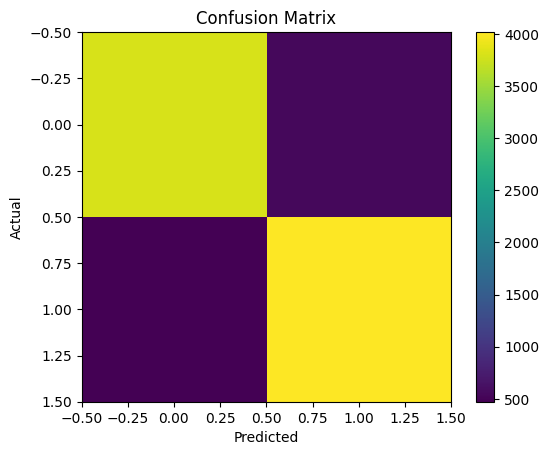

In [96]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Display confusion matrix
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [99]:
# Test a new review
new_review = ["This movie was amazing and I really enjoyed it"]

# Clean the review
new_review_clean = [clean_text(new_review[0])]

# Convert to TF-IDF
new_review_tfidf = tfidf.transform(new_review_clean)

# Predict
prediction = model.predict(new_review_tfidf)

if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

Sentiment: Positive


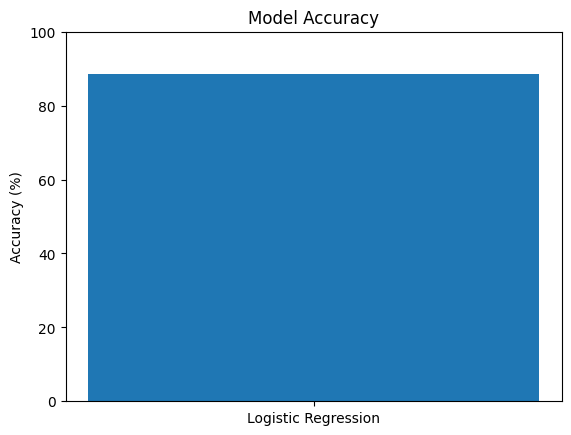

In [100]:
import matplotlib.pyplot as plt

accuracy_percentage = accuracy * 100

plt.bar(["Logistic Regression"], [accuracy_percentage])

plt.title("Model Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [101]:
# Convert numbers back to sentiment names

actual_sentiment = y_test.map({
    0: "Negative",
    1: "Positive"
})

predicted_sentiment = pd.Series(y_pred).map({
    0: "Negative",
    1: "Positive"
})

# Display first 10 predictions

results = pd.DataFrame({
    "Actual": actual_sentiment.values[:10],
    "Predicted": predicted_sentiment.values[:10]
})

results

,Actual,Predicted
0,Positive,Positive
1,Positive,Positive
2,Negative,Negative
3,Negative,Negative
4,Negative,Negative
5,Negative,Positive
6,Positive,Positive
7,Negative,Negative
8,Positive,Negative
9,Negative,Negative


In [102]:
# Test multiple new reviews

new_reviews = [
    "This movie was excellent and I really enjoyed it",
    "The movie was boring and a complete waste of time",
    "Amazing acting and wonderful story",
    "I hated this movie. It was terrible"
]

# Clean the reviews
cleaned_reviews = [clean_text(review) for review in new_reviews]

# Convert to TF-IDF
reviews_tfidf = tfidf.transform(cleaned_reviews)

# Predict
predictions = model.predict(reviews_tfidf)

# Display results
for review, prediction in zip(new_reviews, predictions):
    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

Review: This movie was excellent and I really enjoyed it
Predicted Sentiment: Positive
--------------------------------------------------
Review: The movie was boring and a complete waste of time
Predicted Sentiment: Negative
--------------------------------------------------
Review: Amazing acting and wonderful story
Predicted Sentiment: Positive
--------------------------------------------------
Review: I hated this movie. It was terrible
Predicted Sentiment: Negative
--------------------------------------------------


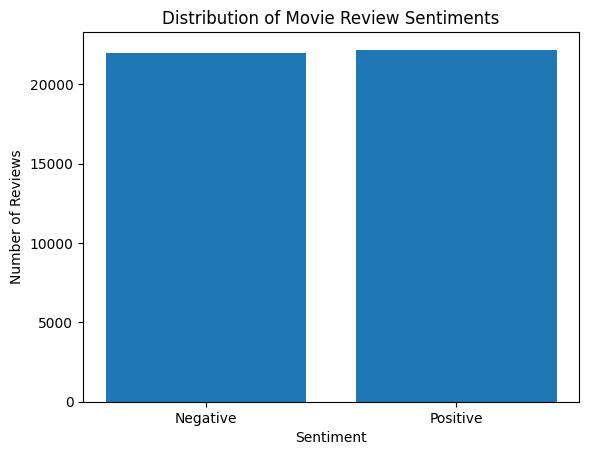

In [103]:
# Count positive and negative reviews

sentiment_counts = df["sentiment"].value_counts()

# Create graph
plt.bar(
    ["Negative", "Positive"],
    [
        sentiment_counts.get(0, 0),
        sentiment_counts.get(1, 0)
    ]
)

plt.title("Distribution of Movie Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [104]:
# Save the cleaned dataset

df.to_csv("IMDB_Cleaned_Dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [106]:
test_review = input("Enter a movie review: ")

# Clean the review
cleaned_test_review = clean_text(test_review)

# Convert to TF-IDF
test_review_tfidf = tfidf.transform([cleaned_test_review])

# Predict
prediction = model.predict(test_review_tfidf)

if prediction[0] == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

Enter a movie review: the movie was lag
Predicted Sentiment: Negative
